In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from numba import jit
import scipy
import pandas as pd
import seaborn as sns
import os
from scipy.ndimage import uniform_filter1d
from plotting import *

In [3]:
planets = pd.read_csv("../input/planets_triple.csv")

In [4]:
triples = pd.read_csv('../input/final_triple_5.csv')

In [5]:
triples.head()

,Ime sustava,Orbitalna konfiguracija,Oznaka matične zvijezde,Ime zvijezde A,Ime zvijezde B,Ime zvijezde C,Masa A [m_s],Masa B [m_s],Masa C [m_s],Radijus A [R_s],...,i_u [º],Omega_u [º],omega_u [º],Oznake vanjskog para,a_v [AU],e_v,i_v [º],Omega_v [º],omega_v [º],Izvori
0,Gliese 667,S(C),C,Gliese 667 A,Gliese 667 B,Gliese 667 C,0.730,0.690,0.310,0.760,...,127.600,133.200,68.100,AB-C,230.0,NaN,NaN,NaN,NaN,"[14], [17], [18], [19], [20]"
1,LTT 1445,S(C),C,LTT 1445 B,LTT 1445 C,LTT 1445 A,0.257,0.215,0.161,0.271,...,89.640,137.630,209.000,A-BC,34.0,NaN,92.52,NaN,NaN,"[14], [17], [20], [21], [22]"
2,94 Ceti,S(C),C,94 Ceti B,94 Ceti C,94 Ceti A,1.300,0.550,0.340,1.898,...,108.323,191.496,334.895,A-BC,220.0,0.26,104.00,97.0,342.0,"[14], [17], [19], [23], [24], [25]"
3,Kepler-444,S(C),C,Kepler-444 B,Kepler-444 C,Kepler-444 A,0.754,0.307,0.296,0.753,...,NaN,NaN,NaN,A-BC,52.2,0.55,85.40,250.7,227.3,"[14], [17], [19], [20], [26]"
4,HD 132563,S(C),C,HD 132563 Aa,HD 132563 Ab,HD 132563 B,1.081,0.600,1.010,1.300,...,NaN,NaN,160.200,AB-C,400.0,NaN,NaN,NaN,NaN,"[14], [17], [19], [20], [27], [28]"


In [6]:
from integrator import run_system
from integrator.experiments import generate_habitability_experiments
from integrator.batch import recommended_dt

In [14]:
configs = generate_habitability_experiments(
    triples,
    planets,
    tf=1e5,
    output_dir='../output',
)

# Compute dt and output cadence for each config
for cfg in configs:
    cfg["dt"] = recommended_dt(cfg)
    cfg["output_every_n"] = max(1, int(1.0 / cfg["dt"]))  # ~1 snapshot per year

print(f"Generated {len(configs)} experiment configs")
print(f"tf = {configs[0]['tf']:.0f} yr")
print(f"Example dt = {configs[0]['dt']:.6g} yr")
print(f"Example output_every_n = {configs[0]['output_every_n']}")
print(f"Example snapshots = {int(configs[0]['tf'] / configs[0]['dt'] / configs[0]['output_every_n'])}")

Generated 91 experiment configs
tf = 100000 yr
Example dt = 0.00203401 yr
Example output_every_n = 491
Example snapshots = 100130


In [15]:
preview_df = pd.DataFrame([
    {
        'system_name': cfg['system_name'],
        'planet_scenario': cfg['planet_scenario'],
        'host_star': cfg['host_star'],
        'system_type': cfg['system_type'],
        'outer_e': cfg['outer_e'],
        'outer_i': cfg['outer_i'],
        'source_outer_e': cfg['source_outer_e'],
        'source_outer_i': cfg['source_outer_i'],
        'source_inner_e': cfg['source_inner_e'],
        'source_inner_i': cfg['source_inner_i'],
        'n_planets': len(cfg['planets']),
        'experiment_name': cfg['experiment_name'],
        'output_file': cfg['output_file'],
    }
    for cfg in configs
])

summary_df = (
    preview_df.groupby(['system_name', 'planet_scenario'], as_index=False)
    .agg(
        n_runs=('experiment_name', 'size'),
        outer_e_values=('outer_e', lambda s: sorted(pd.unique(s))),
        outer_i_values=('outer_i', lambda s: sorted(pd.unique(s))),
        n_planets=('n_planets', 'first'),
    )
    .sort_values(['system_name', 'planet_scenario'])
)

print(f"Total configs: {len(preview_df)}")
display(summary_df)
display(preview_df.head(20))

Total configs: 91


,system_name,planet_scenario,n_runs,outer_e_values,outer_i_values,n_planets
0,94 Ceti,hz_inner,1,[0.26],[104.0],2
1,94 Ceti,hz_mid,1,[0.26],[104.0],2
2,94 Ceti,hz_outer,1,[0.26],[104.0],2
3,Gliese 667,observed,20,"[0.0, 0.2, 0.4, 0.6, 0.8]","[0.0, 30.0, 60.0, 90.0]",5
4,HD 132563,hz_inner,20,"[0.0, 0.2, 0.4, 0.6, 0.8]","[0.0, 30.0, 60.0, 90.0]",2
5,HD 132563,hz_mid,20,"[0.0, 0.2, 0.4, 0.6, 0.8]","[0.0, 30.0, 60.0, 90.0]",2
6,HD 132563,hz_outer,20,"[0.0, 0.2, 0.4, 0.6, 0.8]","[0.0, 30.0, 60.0, 90.0]",2
7,Kepler-444,hz_inner,1,[0.55],[85.4],6
8,Kepler-444,hz_mid,1,[0.55],[85.4],6
9,Kepler-444,hz_outer,1,[0.55],[85.4],6


,system_name,planet_scenario,host_star,system_type,outer_e,outer_i,source_outer_e,source_outer_i,source_inner_e,source_inner_i,n_planets,experiment_name,output_file
0,Gliese 667,observed,C,S(C),0.0,0.0,NaN,NaN,0.57,127.6,5,Gliese_667_observed_ev0.0_iv000,../output/Gliese_667_observed_ev0.0_iv000.hdf5
1,Gliese 667,observed,C,S(C),0.0,30.0,NaN,NaN,0.57,127.6,5,Gliese_667_observed_ev0.0_iv030,../output/Gliese_667_observed_ev0.0_iv030.hdf5
2,Gliese 667,observed,C,S(C),0.0,60.0,NaN,NaN,0.57,127.6,5,Gliese_667_observed_ev0.0_iv060,../output/Gliese_667_observed_ev0.0_iv060.hdf5
3,Gliese 667,observed,C,S(C),0.0,90.0,NaN,NaN,0.57,127.6,5,Gliese_667_observed_ev0.0_iv090,../output/Gliese_667_observed_ev0.0_iv090.hdf5
4,Gliese 667,observed,C,S(C),0.2,0.0,NaN,NaN,0.57,127.6,5,Gliese_667_observed_ev0.2_iv000,../output/Gliese_667_observed_ev0.2_iv000.hdf5
5,Gliese 667,observed,C,S(C),0.2,30.0,NaN,NaN,0.57,127.6,5,Gliese_667_observed_ev0.2_iv030,../output/Gliese_667_observed_ev0.2_iv030.hdf5
6,Gliese 667,observed,C,S(C),0.2,60.0,NaN,NaN,0.57,127.6,5,Gliese_667_observed_ev0.2_iv060,../output/Gliese_667_observed_ev0.2_iv060.hdf5
7,Gliese 667,observed,C,S(C),0.2,90.0,NaN,NaN,0.57,127.6,5,Gliese_667_observed_ev0.2_iv090,../output/Gliese_667_observed_ev0.2_iv090.hdf5
8,Gliese 667,observed,C,S(C),0.4,0.0,NaN,NaN,0.57,127.6,5,Gliese_667_observed_ev0.4_iv000,../output/Gliese_667_observed_ev0.4_iv000.hdf5
9,Gliese 667,observed,C,S(C),0.4,30.0,NaN,NaN,0.57,127.6,5,Gliese_667_observed_ev0.4_iv030,../output/Gliese_667_observed_ev0.4_iv030.hdf5


In [8]:
# --- Post-processing: compute orbital elements, energy, temperature, HZ ---
from integrator import postprocess

for i, cfg in enumerate(configs):
    path = cfg['output_file']
    if os.path.exists(path):
        print(f"[{i+1}/{len(configs)}] Post-processing: {cfg['experiment_name']}")
        try:
            postprocess(path)
        except Exception as exc:
            print(f"  FAIL: {exc}")
    else:
        print(f"[{i+1}/{len(configs)}] Missing: {cfg['experiment_name']}")

print("Post-processing complete.")

[1/91] Post-processing: Gliese_667_observed_ev0.0_iv000
[2/91] Post-processing: Gliese_667_observed_ev0.0_iv030
[3/91] Post-processing: Gliese_667_observed_ev0.0_iv060
[4/91] Post-processing: Gliese_667_observed_ev0.0_iv090
[5/91] Post-processing: Gliese_667_observed_ev0.2_iv000
[6/91] Post-processing: Gliese_667_observed_ev0.2_iv030
[7/91] Post-processing: Gliese_667_observed_ev0.2_iv060
[8/91] Post-processing: Gliese_667_observed_ev0.2_iv090
[9/91] Post-processing: Gliese_667_observed_ev0.4_iv000
[10/91] Post-processing: Gliese_667_observed_ev0.4_iv030
[11/91] Post-processing: Gliese_667_observed_ev0.4_iv060
[12/91] Post-processing: Gliese_667_observed_ev0.4_iv090
[13/91] Post-processing: Gliese_667_observed_ev0.6_iv000
[14/91] Post-processing: Gliese_667_observed_ev0.6_iv030
[15/91] Post-processing: Gliese_667_observed_ev0.6_iv060
[16/91] Post-processing: Gliese_667_observed_ev0.6_iv090
[17/91] Post-processing: Gliese_667_observed_ev0.8_iv000
[18/91] Post-processing: Gliese_667_obse

FileNotFoundError: [Errno 2] No such file or directory: '../plots/Gliese_667_observed_ev0.0_iv000.png'

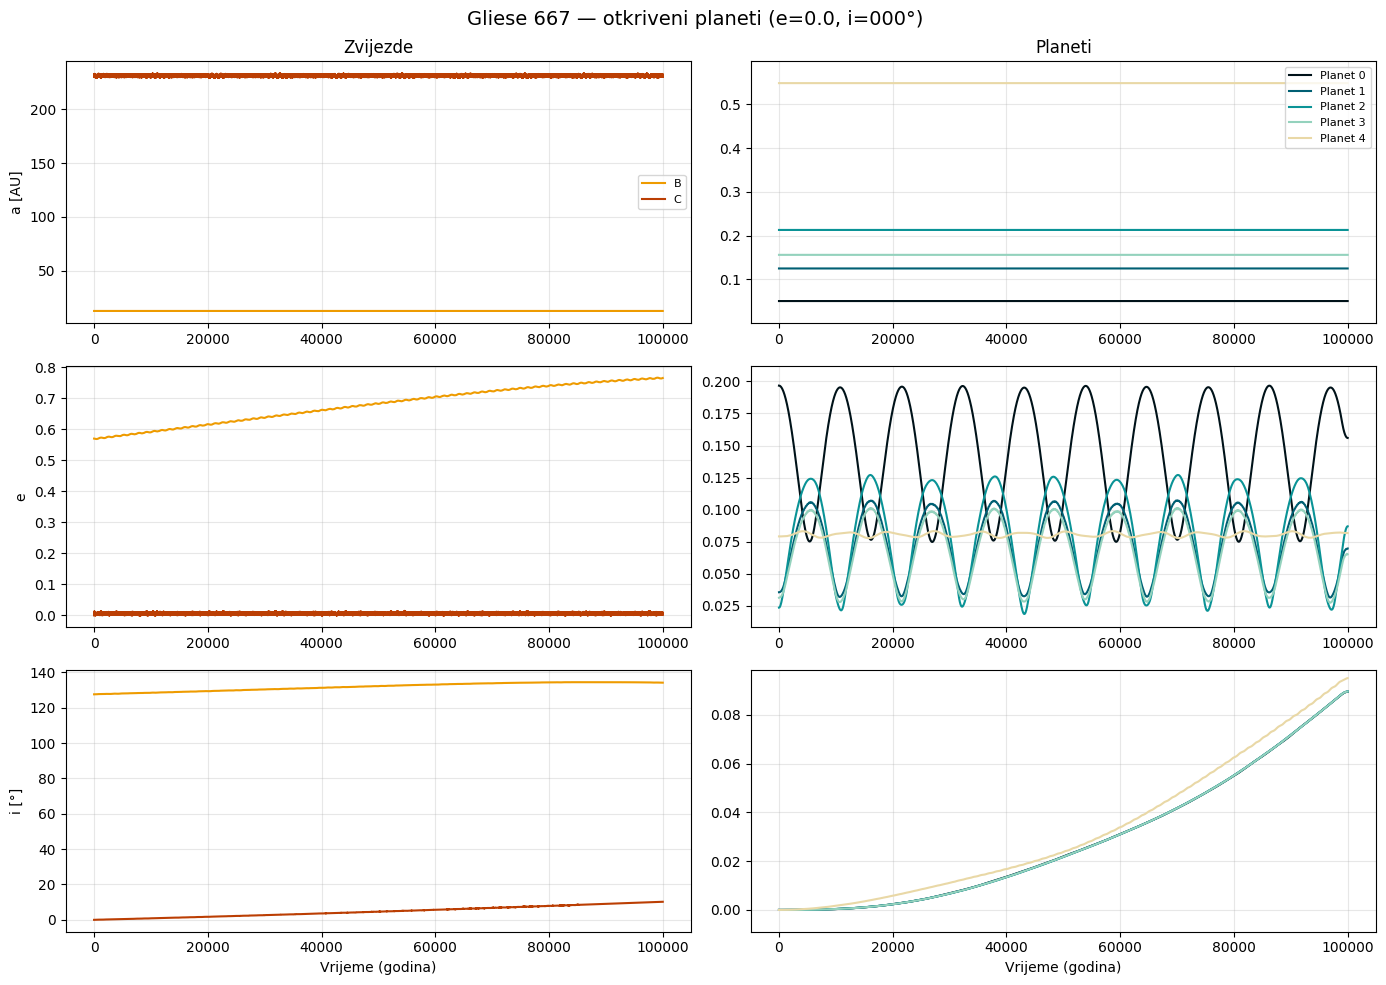

In [9]:
for i, cfg in enumerate(configs):
    path = cfg['output_file']
    if os.path.exists(path):
        plot_orbital_elements(path, star_smooth=1, planet_smooth=2000, save=cfg['experiment_name']+'.png')
    else:
        print('skipped', cfg['output_file'])

[[6168.   nan 5985.   nan]
 [6168.   nan 5985.   nan]
 [6168.   nan 5985.   nan]
 ...
 [6168.   nan 5985.   nan]
 [6168.   nan 5985.   nan]
 [6168.   nan 5985.   nan]]


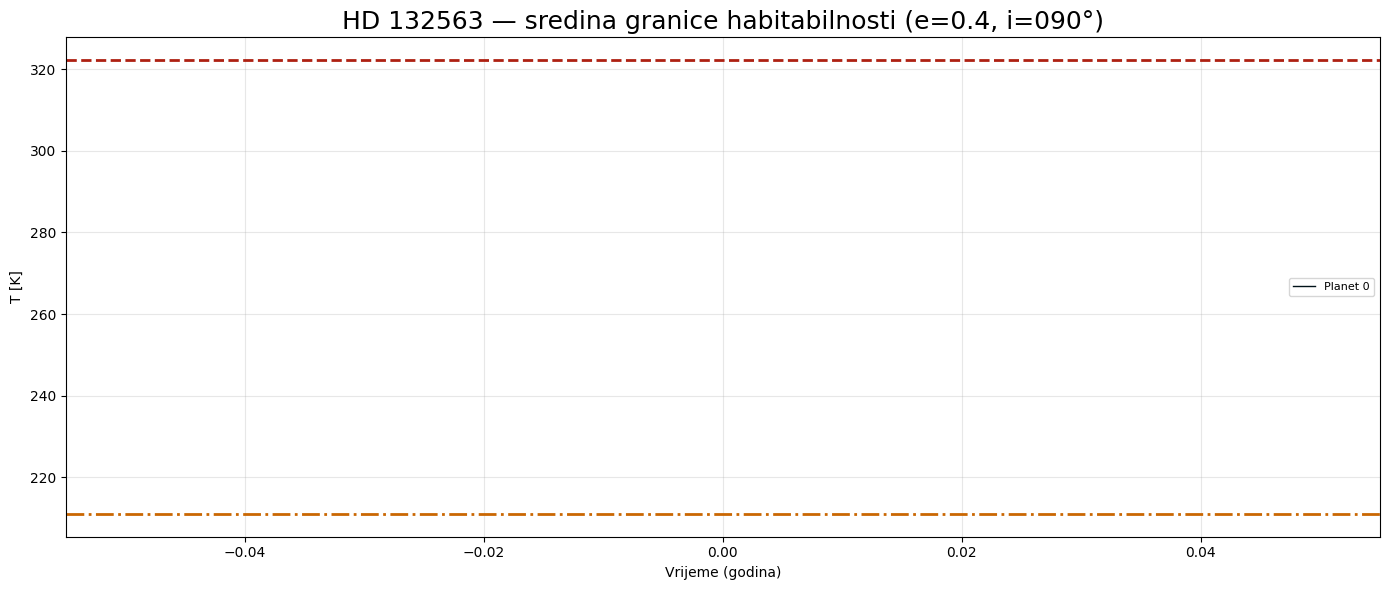

In [37]:
path = '../output/HD_132563_hz_mid_ev0.4_iv090.hdf5'
#path = '../output/94_Ceti_hz_mid_ev0.3_iv104.hdf5'

plot_temperature(path, planet_smooth=1)

E0 = -14.39957273107191
max |ΔE/E0| = 2.3434359229727745e-08


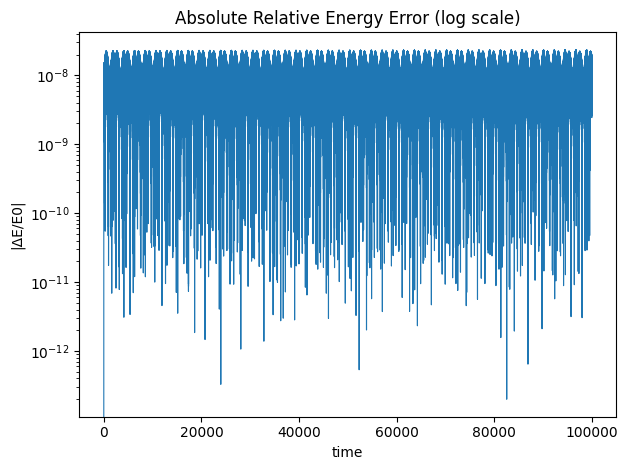

[-14.39957273 -14.39957251 -14.39957272 -14.3995726  -14.39957258
 -14.39957273 -14.39957251 -14.39957272 -14.3995726  -14.39957259]


In [ ]:
mask = np.isfinite(energy) & np.isfinite(t)
t = t[mask]
energy = energy[mask]

E0 = energy[0]
dE = energy - E0
rel = dE / abs(E0)

print("E0 =", E0)
print("max |ΔE/E0| =", np.max(np.abs(rel)))

plt.figure()
 
# Absolute relative error (paper-style)
plt.semilogy(t, np.abs(dE/E0), lw=0.8)
plt.xlabel("time")
plt.ylabel("|ΔE/E0|")
plt.title("Absolute Relative Energy Error (log scale)")

plt.tight_layout()
plt.show()


print(energy[:10])